# ES Futures 5-Min Trend Trading Strategy

**Strategy Overview:**
- Entry: Limit order at 9 EMA when gap between 9/15 EMA <= 2.5 points
- Long: EMA9 > EMA15
- Short: EMA9 < EMA15
- Scale-in: Add 2nd contract at +4 points profit (if margin available)
- Exit: RSI trend break (RSI <= 48 for longs, RSI >= 52 for shorts)

**Data:** Yahoo Finance ^GSPC 5-minute bars (mocking ES futures)

In [16]:
# Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("Libraries imported successfully")

Libraries imported successfully


In [17]:
# Strategy Configuration
MAX_EMA_GAP = 2.5          # Maximum points between EMA9 and EMA15 for entry
RSI_EXIT_LONG = 48         # RSI threshold to exit longs (trend break)
RSI_EXIT_SHORT = 52        # RSI threshold to exit shorts (trend break)
SCALE_IN_PTS = 4           # Points of profit before adding 2nd contract

# Market Parameters
ES_POINT_VALUE = 50        # $50 per ES point
MARGIN_PER_CONTRACT = 14000  # ES margin requirement
STARTING_CAPITAL = 50000   # Starting account balance
MARGIN_BUFFER = 0.20       # Don't use more than 80% of available margin

# Indicator Periods
EMA_FAST = 9
EMA_SLOW = 15
RSI_PERIOD = 14

print(f"Strategy Parameters Loaded:")
print(f"  EMA Gap Filter: <= {MAX_EMA_GAP} points")
print("  Entry Confirmation: EMA direction only (RSI removed)")
print(f"  Scale-in Distance: {SCALE_IN_PTS} points")
print(f"  RSI Exit Long: <= {RSI_EXIT_LONG}")
print(f"  RSI Exit Short: >= {RSI_EXIT_SHORT}")
print(f"  Starting Capital: ${STARTING_CAPITAL:,}")

Strategy Parameters Loaded:
  EMA Gap Filter: <= 2.5 points
  Entry Confirmation: EMA direction only (RSI removed)
  Scale-in Distance: 4 points
  RSI Exit Long: <= 48
  RSI Exit Short: >= 52
  Starting Capital: $50,000


In [18]:
# Fetch 5-minute SPX data (mocking ES futures)
print("Fetching 5-minute SPX data from Yahoo Finance...")
ticker = "^GSPC"
data = yf.download(ticker, period="60d", interval="5m", progress=False)

# Clean data
data = data.dropna()
data.columns = data.columns.get_level_values(0)  # Flatten MultiIndex if present

print(f"Data fetched: {len(data)} bars")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print(f"\nFirst 3 bars:")
print(data.head(3))

Fetching 5-minute SPX data from Yahoo Finance...
Data fetched: 4556 bars
Date range: 2025-12-26 14:30:00+00:00 to 2026-03-24 19:55:00+00:00

First 3 bars:
Price                           Close         High          Low         Open  \
Datetime                                                                       
2025-12-26 14:30:00+00:00  6938.77002  6940.540039  6932.430176  6936.020020   
2025-12-26 14:35:00+00:00  6942.22998  6942.709961  6937.359863  6938.520020   
2025-12-26 14:40:00+00:00  6944.47998  6944.799805  6941.359863  6942.180176   

Price                        Volume  
Datetime                             
2025-12-26 14:30:00+00:00         0  
2025-12-26 14:35:00+00:00  25914450  
2025-12-26 14:40:00+00:00  22664063  


In [19]:
# Calculate Technical Indicators

# EMA 9 and EMA 15
data['EMA9'] = data['Close'].ewm(span=EMA_FAST, adjust=False).mean()
data['EMA15'] = data['Close'].ewm(span=EMA_SLOW, adjust=False).mean()
data['ema_gap'] = abs(data['EMA9'] - data['EMA15'])

# RSI (Wilder's smoothing method)
delta = data['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.ewm(com=RSI_PERIOD-1, adjust=False).mean()
avg_loss = loss.ewm(com=RSI_PERIOD-1, adjust=False).mean()

rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

print("Technical indicators calculated:")
print(f"\nSample data (bar 50):")
sample_idx = min(50, len(data)-1)
print(f"  Close: {data['Close'].iloc[sample_idx]:.2f}")
print(f"  EMA9: {data['EMA9'].iloc[sample_idx]:.2f}")
print(f"  EMA15: {data['EMA15'].iloc[sample_idx]:.2f}")
print(f"  EMA Gap: {data['ema_gap'].iloc[sample_idx]:.2f}")
print(f"  RSI: {data['RSI'].iloc[sample_idx]:.2f}")

# Check for NaN values
print(f"\nNaN counts:")
print(data[['EMA9', 'EMA15', 'RSI']].isna().sum())

Technical indicators calculated:

Sample data (bar 50):
  Close: 6927.73
  EMA9: 6926.83
  EMA15: 6926.86
  EMA Gap: 0.03
  RSI: 49.91

NaN counts:
Price
EMA9     0
EMA15    0
RSI      1
dtype: int64


In [20]:
# Backtest Engine Initialization

# Account state
account_balance = STARTING_CAPITAL
equity_curve = []

# Position state
in_position = False
direction = None  # 'long' or 'short'
contracts = 0
entry_price = 0.0
scale_in_done = False

# Limit order state
limit_pending = False
limit_price = 0.0
limit_direction = None

# Trade tracking
trade_log = []
entry_signals = []  # For charting
exit_signals = []   # For charting

print("Backtest initialized")
print(f"Starting balance: ${account_balance:,.2f}")
print(f"Max contracts (margin): {int(STARTING_CAPITAL * (1 - MARGIN_BUFFER) / MARGIN_PER_CONTRACT)}")
print(f"Starting backtest from bar 30 (allowing indicator warmup)...")

Backtest initialized
Starting balance: $50,000.00
Max contracts (margin): 2
Starting backtest from bar 30 (allowing indicator warmup)...


In [21]:
# Main Backtest Loop

for i in range(30, len(data)):
    bar_time = data.index[i]
    high = data['High'].iloc[i]
    low = data['Low'].iloc[i]
    close = data['Close'].iloc[i]
    ema9 = data['EMA9'].iloc[i]
    ema15 = data['EMA15'].iloc[i]
    ema_gap = data['ema_gap'].iloc[i]
    rsi = data['RSI'].iloc[i]

    # Skip if indicators are NaN
    if pd.isna(ema9) or pd.isna(ema15) or pd.isna(rsi):
        equity_curve.append(account_balance)
        continue

    # Calculate unrealized P&L for equity curve
    unrealized_pnl = 0.0
    if in_position and contracts > 0:
        if direction == 'long':
            unrealized_pnl = (close - entry_price) * contracts * ES_POINT_VALUE
        else:
            unrealized_pnl = (entry_price - close) * contracts * ES_POINT_VALUE

    equity = account_balance + unrealized_pnl
    equity_curve.append(equity)

    # 1) Check limit fill
    if limit_pending:
        filled = False
        fill_price = limit_price

        if limit_direction == 'long' and low <= limit_price:
            filled = True
        elif limit_direction == 'short' and high >= limit_price:
            filled = True

        if filled:
            in_position = True
            direction = limit_direction
            contracts = 1
            entry_price = fill_price
            scale_in_done = False
            limit_pending = False

            entry_signals.append({
                'time': bar_time,
                'price': entry_price,
                'direction': direction
            })
        else:
            # Expire unfilled limit each bar
            limit_pending = False

    # 2) Check RSI exit
    if in_position:
        exit_triggered = False

        if direction == 'long' and rsi <= RSI_EXIT_LONG:
            exit_triggered = True
        elif direction == 'short' and rsi >= RSI_EXIT_SHORT:
            exit_triggered = True

        if exit_triggered:
            exit_price = close

            if direction == 'long':
                pnl = (exit_price - entry_price) * contracts * ES_POINT_VALUE
            else:
                pnl = (entry_price - exit_price) * contracts * ES_POINT_VALUE

            account_balance += pnl

            trade_log.append({
                'entry_time': entry_signals[-1]['time'],
                'exit_time': bar_time,
                'direction': direction,
                'entry_price': entry_price,
                'exit_price': exit_price,
                'contracts': contracts,
                'pnl': pnl,
                'exit_reason': 'RSI_TREND_BREAK',
                'scale_in': scale_in_done
            })

            exit_signals.append({
                'time': bar_time,
                'price': exit_price,
                'direction': direction
            })

            in_position = False
            direction = None
            contracts = 0
            entry_price = 0.0
            scale_in_done = False

    # 3) Scale-in after +4 points
    if in_position and not scale_in_done and contracts == 1:
        scale_in_triggered = False

        if direction == 'long' and high >= entry_price + SCALE_IN_PTS:
            scale_in_triggered = True
        elif direction == 'short' and low <= entry_price - SCALE_IN_PTS:
            scale_in_triggered = True

        if scale_in_triggered:
            margin_used = contracts * MARGIN_PER_CONTRACT
            margin_available = account_balance * (1 - MARGIN_BUFFER) - margin_used

            if margin_available >= MARGIN_PER_CONTRACT:
                contracts = 2
                scale_in_done = True

    # 4) New limit order (RSI confirmation removed)
    if not in_position and not limit_pending:
        long_signal = ema_gap <= MAX_EMA_GAP and ema9 > ema15
        short_signal = ema_gap <= MAX_EMA_GAP and ema9 < ema15

        if long_signal:
            limit_pending = True
            limit_price = ema9
            limit_direction = 'long'
        elif short_signal:
            limit_pending = True
            limit_price = ema9
            limit_direction = 'short'

# End-of-data close
if in_position:
    final_close = data['Close'].iloc[-1]
    final_time = data.index[-1]

    if direction == 'long':
        pnl = (final_close - entry_price) * contracts * ES_POINT_VALUE
    else:
        pnl = (entry_price - final_close) * contracts * ES_POINT_VALUE

    account_balance += pnl

    trade_log.append({
        'entry_time': entry_signals[-1]['time'],
        'exit_time': final_time,
        'direction': direction,
        'entry_price': entry_price,
        'exit_price': final_close,
        'contracts': contracts,
        'pnl': pnl,
        'exit_reason': 'END_OF_DATA',
        'scale_in': scale_in_done
    })

    exit_signals.append({
        'time': final_time,
        'price': final_close,
        'direction': direction
    })

print(f"\nBacktest complete!")
print(f"Total trades executed: {len(trade_log)}")
print(f"Final account balance: ${account_balance:,.2f}")
print(f"Total P&L: ${account_balance - STARTING_CAPITAL:,.2f}")


Backtest complete!
Total trades executed: 391
Final account balance: $-13,280.80
Total P&L: $-63,280.80


In [22]:
# Performance Metrics

if len(trade_log) > 0:
    trades_df = pd.DataFrame(trade_log)

    total_pnl = trades_df['pnl'].sum()
    winning_trades = trades_df[trades_df['pnl'] > 0]
    losing_trades = trades_df[trades_df['pnl'] < 0]

    num_wins = len(winning_trades)
    num_losses = len(losing_trades)
    win_rate = (num_wins / len(trades_df)) * 100 if len(trades_df) > 0 else 0

    avg_win = winning_trades['pnl'].mean() if num_wins > 0 else 0
    avg_loss = losing_trades['pnl'].mean() if num_losses > 0 else 0

    total_wins = winning_trades['pnl'].sum() if num_wins > 0 else 0
    total_losses = abs(losing_trades['pnl'].sum()) if num_losses > 0 else 0
    profit_factor = total_wins / total_losses if total_losses > 0 else float('inf')

    equity_series = pd.Series(equity_curve)
    running_max = equity_series.expanding().max()
    drawdown = equity_series - running_max
    max_drawdown = drawdown.min()
    max_drawdown_pct = (max_drawdown / running_max.max()) * 100 if running_max.max() > 0 else 0

    scaled_trades = trades_df[trades_df['scale_in'] == True]
    num_scaled = len(scaled_trades)

    print("=" * 60)
    print("PERFORMANCE METRICS")
    print("=" * 60)
    print(f"Total Trades:          {len(trades_df)}")
    print(f"Winning Trades:        {num_wins} ({win_rate:.1f}%)")
    print(f"Losing Trades:         {num_losses}")
    print(f"Trades with Scale-In:  {num_scaled} ({(num_scaled/len(trades_df)*100):.1f}%)")
    print()
    print(f"Total P&L:             ${total_pnl:,.2f}")
    print(f"Average Win:           ${avg_win:,.2f}")
    print(f"Average Loss:          ${avg_loss:,.2f}")
    print(f"Profit Factor:         {profit_factor:.2f}")
    print()
    print(f"Max Drawdown:          ${max_drawdown:,.2f} ({max_drawdown_pct:.2f}%)")
    print(f"Final Balance:         ${account_balance:,.2f}")
    print(f"Return:                {((account_balance - STARTING_CAPITAL) / STARTING_CAPITAL * 100):.2f}%")
    print("=" * 60)

    print("\nFirst 5 Trades:")
    print(trades_df.head(5)[['entry_time', 'direction', 'entry_price', 'exit_price', 'contracts', 'pnl', 'exit_reason', 'scale_in']].to_string(index=False))
else:
    print("No trades executed during backtest period.")

PERFORMANCE METRICS
Total Trades:          391
Winning Trades:        54 (13.8%)
Losing Trades:         337
Trades with Scale-In:  69 (17.6%)

Total P&L:             $-63,280.80
Average Win:           $1,808.44
Average Loss:          $-477.56
Profit Factor:         0.61

Max Drawdown:          $-80,759.26 (-119.68%)
Final Balance:         $-13,280.80
Return:                -126.56%

First 5 Trades:
               entry_time direction  entry_price  exit_price  contracts          pnl     exit_reason  scale_in
2025-12-26 17:25:00+00:00     short  6926.350941 6930.209961          2  -385.901980 RSI_TREND_BREAK      True
2025-12-26 19:15:00+00:00      long  6930.201822 6928.459961          1   -87.093056 RSI_TREND_BREAK     False
2025-12-26 20:55:00+00:00      long  6930.339802 6907.959961          1 -1118.992035 RSI_TREND_BREAK     False
2025-12-29 15:40:00+00:00     short  6907.074033 6899.560059          2   751.397457 RSI_TREND_BREAK      True
2025-12-29 18:50:00+00:00      long  6900.8

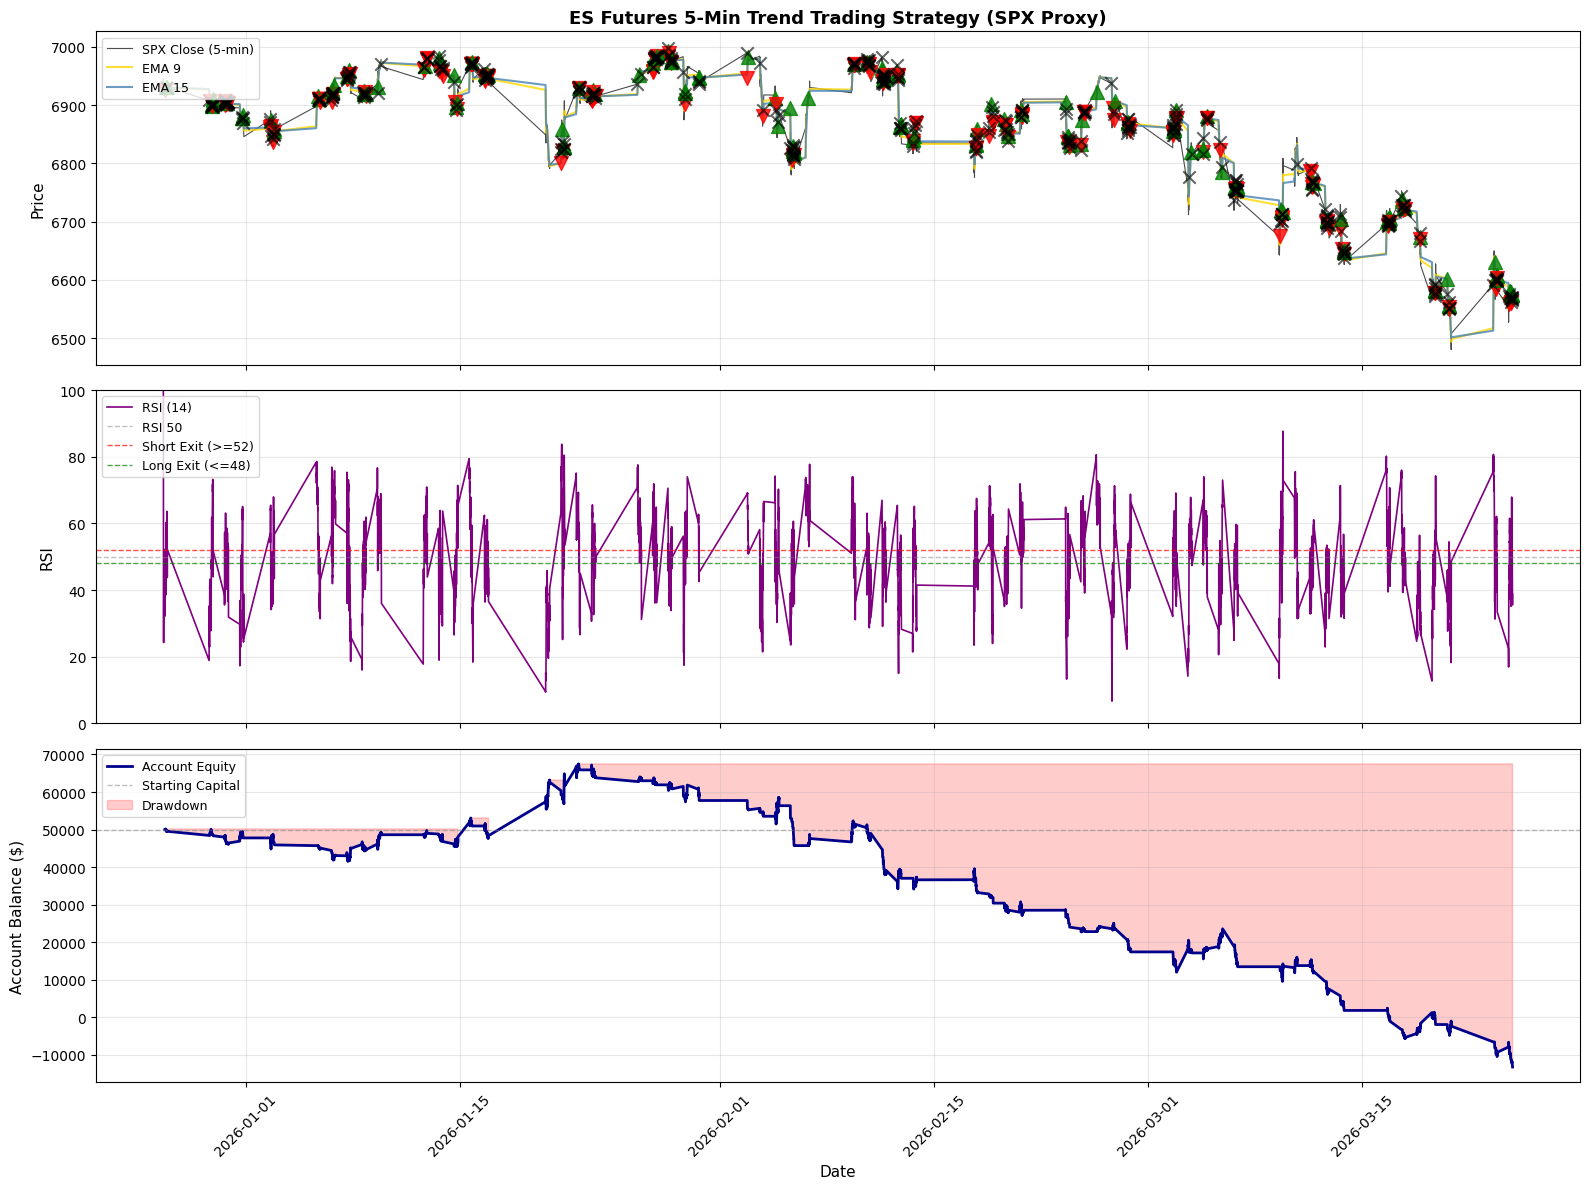


Chart complete!


In [23]:
# Visualization: 3-Panel Chart

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Panel 1: Price + EMAs + Entry/Exit Signals
ax1.plot(data.index, data['Close'], label='SPX Close (5-min)', color='black', linewidth=0.8, alpha=0.7)
ax1.plot(data.index, data['EMA9'], label='EMA 9', color='gold', linewidth=1.5, alpha=0.8)
ax1.plot(data.index, data['EMA15'], label='EMA 15', color='steelblue', linewidth=1.5, alpha=0.8)

for signal in entry_signals:
    marker = '^' if signal['direction'] == 'long' else 'v'
    color = 'green' if signal['direction'] == 'long' else 'red'
    ax1.scatter(signal['time'], signal['price'], marker=marker, color=color, s=100, zorder=5, alpha=0.8)

for signal in exit_signals:
    ax1.scatter(signal['time'], signal['price'], marker='x', color='black', s=80, zorder=5, alpha=0.6)

ax1.set_ylabel('Price', fontsize=11)
ax1.set_title('ES Futures 5-Min Trend Trading Strategy (SPX Proxy)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: RSI (exit thresholds)
ax2.plot(data.index, data['RSI'], label='RSI (14)', color='purple', linewidth=1.2)
ax2.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='RSI 50')
ax2.axhline(y=RSI_EXIT_SHORT, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Short Exit (>={RSI_EXIT_SHORT})')
ax2.axhline(y=RSI_EXIT_LONG, color='green', linestyle='--', linewidth=1, alpha=0.7, label=f'Long Exit (<={RSI_EXIT_LONG})')

ax2.set_ylabel('RSI', fontsize=11)
ax2.set_ylim([0, 100])
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3: Equity Curve
equity_index = data.index[30:30 + len(equity_curve)]
ax3.plot(equity_index, equity_curve, label='Account Equity', color='darkblue', linewidth=2)
ax3.axhline(y=STARTING_CAPITAL, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Starting Capital')

if len(equity_curve) > 0:
    equity_series = pd.Series(equity_curve, index=equity_index)
    running_max = equity_series.expanding().max()
    ax3.fill_between(equity_series.index, equity_series, running_max, where=(equity_series < running_max), color='red', alpha=0.2, label='Drawdown')

ax3.set_ylabel('Account Balance ($)', fontsize=11)
ax3.set_xlabel('Date', fontsize=11)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nChart complete!")

In [26]:
# Picture-Based Strategy: The Trend Trade
# Rules interpreted from the screenshot:
# 1) 5-min chart
# 2) Entry filter: abs(EMA9 - EMA15) <= 2.5
# 3) Entry type: limit at EMA9 with 1 contract, no initial stop
# 4) Add 2nd contract after +4 points in favor
# 5) Stop location: 4 points past 2nd entry
# 6) Exit criteria: take 1 contract at 2/3 points (modeled as 2.5 points)

PIC_MAX_EMA_GAP = 2.5
PIC_SECOND_ENTRY_TRIGGER = 4.0
PIC_STOP_FROM_SECOND_ENTRY = 4.0
PIC_PARTIAL_EXIT_POINTS = 2.5  # midpoint of 2/3 points from image

pic_account_balance = STARTING_CAPITAL
pic_equity_curve = []

pic_in_position = False
pic_direction = None
pic_entries = []
pic_contracts = 0
pic_partial_exit_done = False
pic_second_entry_done = False
pic_stop_price = None

pic_limit_pending = False
pic_limit_direction = None
pic_limit_price = 0.0

pic_trade_log = []
pic_entry_signals = []
pic_exit_signals = []

for i in range(30, len(data)):
    bar_time = data.index[i]
    high = data['High'].iloc[i]
    low = data['Low'].iloc[i]
    close = data['Close'].iloc[i]
    ema9 = data['EMA9'].iloc[i]
    ema15 = data['EMA15'].iloc[i]
    ema_gap = data['ema_gap'].iloc[i]

    if pd.isna(ema9) or pd.isna(ema15):
        pic_equity_curve.append(pic_account_balance)
        continue

    # Mark-to-market equity
    if pic_in_position and pic_contracts > 0:
        avg_entry = float(np.mean(pic_entries))
        if pic_direction == 'long':
            unrealized = (close - avg_entry) * pic_contracts * ES_POINT_VALUE
        else:
            unrealized = (avg_entry - close) * pic_contracts * ES_POINT_VALUE
    else:
        unrealized = 0.0
    pic_equity_curve.append(pic_account_balance + unrealized)

    # Fill pending EMA9 limit order (expires after this bar if unfilled)
    if pic_limit_pending:
        filled = False
        if pic_limit_direction == 'long' and low <= pic_limit_price:
            filled = True
        elif pic_limit_direction == 'short' and high >= pic_limit_price:
            filled = True

        if filled:
            pic_in_position = True
            pic_direction = pic_limit_direction
            pic_entries = [float(pic_limit_price)]
            pic_contracts = 1
            pic_partial_exit_done = False
            pic_second_entry_done = False
            pic_stop_price = None
            pic_entry_signals.append({'time': bar_time, 'price': float(pic_limit_price), 'direction': pic_direction})

        pic_limit_pending = False

    if pic_in_position:
        avg_entry = float(np.mean(pic_entries))

        # Add 2nd contract after +4 points in favor
        if not pic_second_entry_done and pic_contracts == 1:
            if pic_direction == 'long' and high >= pic_entries[0] + PIC_SECOND_ENTRY_TRIGGER:
                second_entry = pic_entries[0] + PIC_SECOND_ENTRY_TRIGGER
                pic_entries.append(float(second_entry))
                pic_contracts = 2
                pic_second_entry_done = True
                pic_stop_price = float(second_entry - PIC_STOP_FROM_SECOND_ENTRY)
                pic_entry_signals.append({'time': bar_time, 'price': float(second_entry), 'direction': 'long'})
            elif pic_direction == 'short' and low <= pic_entries[0] - PIC_SECOND_ENTRY_TRIGGER:
                second_entry = pic_entries[0] - PIC_SECOND_ENTRY_TRIGGER
                pic_entries.append(float(second_entry))
                pic_contracts = 2
                pic_second_entry_done = True
                pic_stop_price = float(second_entry + PIC_STOP_FROM_SECOND_ENTRY)
                pic_entry_signals.append({'time': bar_time, 'price': float(second_entry), 'direction': 'short'})

        # Partial exit: take 1 contract at +2.5 points (from avg position)
        if pic_contracts == 2 and not pic_partial_exit_done:
            target_hit = False
            if pic_direction == 'long' and high >= avg_entry + PIC_PARTIAL_EXIT_POINTS:
                exit_price = float(avg_entry + PIC_PARTIAL_EXIT_POINTS)
                pnl = (exit_price - avg_entry) * ES_POINT_VALUE
                target_hit = True
            elif pic_direction == 'short' and low <= avg_entry - PIC_PARTIAL_EXIT_POINTS:
                exit_price = float(avg_entry - PIC_PARTIAL_EXIT_POINTS)
                pnl = (avg_entry - exit_price) * ES_POINT_VALUE
                target_hit = True

            if target_hit:
                pic_account_balance += pnl
                pic_contracts = 1
                pic_partial_exit_done = True
                # Keep remaining contract anchored to first entry
                pic_entries = [pic_entries[0]]
                pic_exit_signals.append({'time': bar_time, 'price': exit_price, 'direction': pic_direction, 'reason': 'PARTIAL_2_5PTS'})

        # Stop applies after 2nd entry was established
        if pic_second_entry_done and pic_stop_price is not None and pic_in_position:
            stop_hit = False
            if pic_direction == 'long' and low <= pic_stop_price:
                stop_hit = True
                stop_fill = float(pic_stop_price)
            elif pic_direction == 'short' and high >= pic_stop_price:
                stop_hit = True
                stop_fill = float(pic_stop_price)

            if stop_hit:
                avg_entry = float(np.mean(pic_entries))
                if pic_direction == 'long':
                    pnl = (stop_fill - avg_entry) * pic_contracts * ES_POINT_VALUE
                else:
                    pnl = (avg_entry - stop_fill) * pic_contracts * ES_POINT_VALUE

                pic_account_balance += pnl
                pic_trade_log.append({
                    'entry_time': pic_entry_signals[-1]['time'],
                    'exit_time': bar_time,
                    'direction': pic_direction,
                    'contracts_closed': pic_contracts,
                    'avg_entry': avg_entry,
                    'exit_price': stop_fill,
                    'pnl': pnl,
                    'exit_reason': 'STOP_AFTER_SECOND_ENTRY'
                })
                pic_exit_signals.append({'time': bar_time, 'price': stop_fill, 'direction': pic_direction, 'reason': 'STOP'})

                pic_in_position = False
                pic_direction = None
                pic_entries = []
                pic_contracts = 0
                pic_partial_exit_done = False
                pic_second_entry_done = False
                pic_stop_price = None

    # New EMA9 limit order
    if not pic_in_position and not pic_limit_pending:
        long_signal = ema_gap <= PIC_MAX_EMA_GAP and ema9 > ema15
        short_signal = ema_gap <= PIC_MAX_EMA_GAP and ema9 < ema15

        if long_signal:
            pic_limit_pending = True
            pic_limit_direction = 'long'
            pic_limit_price = float(ema9)
        elif short_signal:
            pic_limit_pending = True
            pic_limit_direction = 'short'
            pic_limit_price = float(ema9)

# End-of-data liquidation
if pic_in_position and pic_contracts > 0:
    final_close = float(data['Close'].iloc[-1])
    final_time = data.index[-1]
    avg_entry = float(np.mean(pic_entries))

    if pic_direction == 'long':
        pnl = (final_close - avg_entry) * pic_contracts * ES_POINT_VALUE
    else:
        pnl = (avg_entry - final_close) * pic_contracts * ES_POINT_VALUE

    pic_account_balance += pnl
    pic_trade_log.append({
        'entry_time': pic_entry_signals[-1]['time'],
        'exit_time': final_time,
        'direction': pic_direction,
        'contracts_closed': pic_contracts,
        'avg_entry': avg_entry,
        'exit_price': final_close,
        'pnl': pnl,
        'exit_reason': 'END_OF_DATA'
    })
    pic_exit_signals.append({'time': final_time, 'price': final_close, 'direction': pic_direction, 'reason': 'EOD'})

print('Picture-based strategy backtest complete')
print(f'Trades closed: {len(pic_trade_log)}')
print(f'Final balance: ${pic_account_balance:,.2f}')
print(f'Total P&L: ${pic_account_balance - STARTING_CAPITAL:,.2f}')

Picture-based strategy backtest complete
Trades closed: 43
Final balance: $35,349.37
Total P&L: $-14,650.63


PICTURE-BASED STRATEGY METRICS
Closed Trades:         43
Win Rate:              0.0%
Profit Factor:         0.00
Total P&L:             $-19,900.63
Final Balance:         $35,349.37


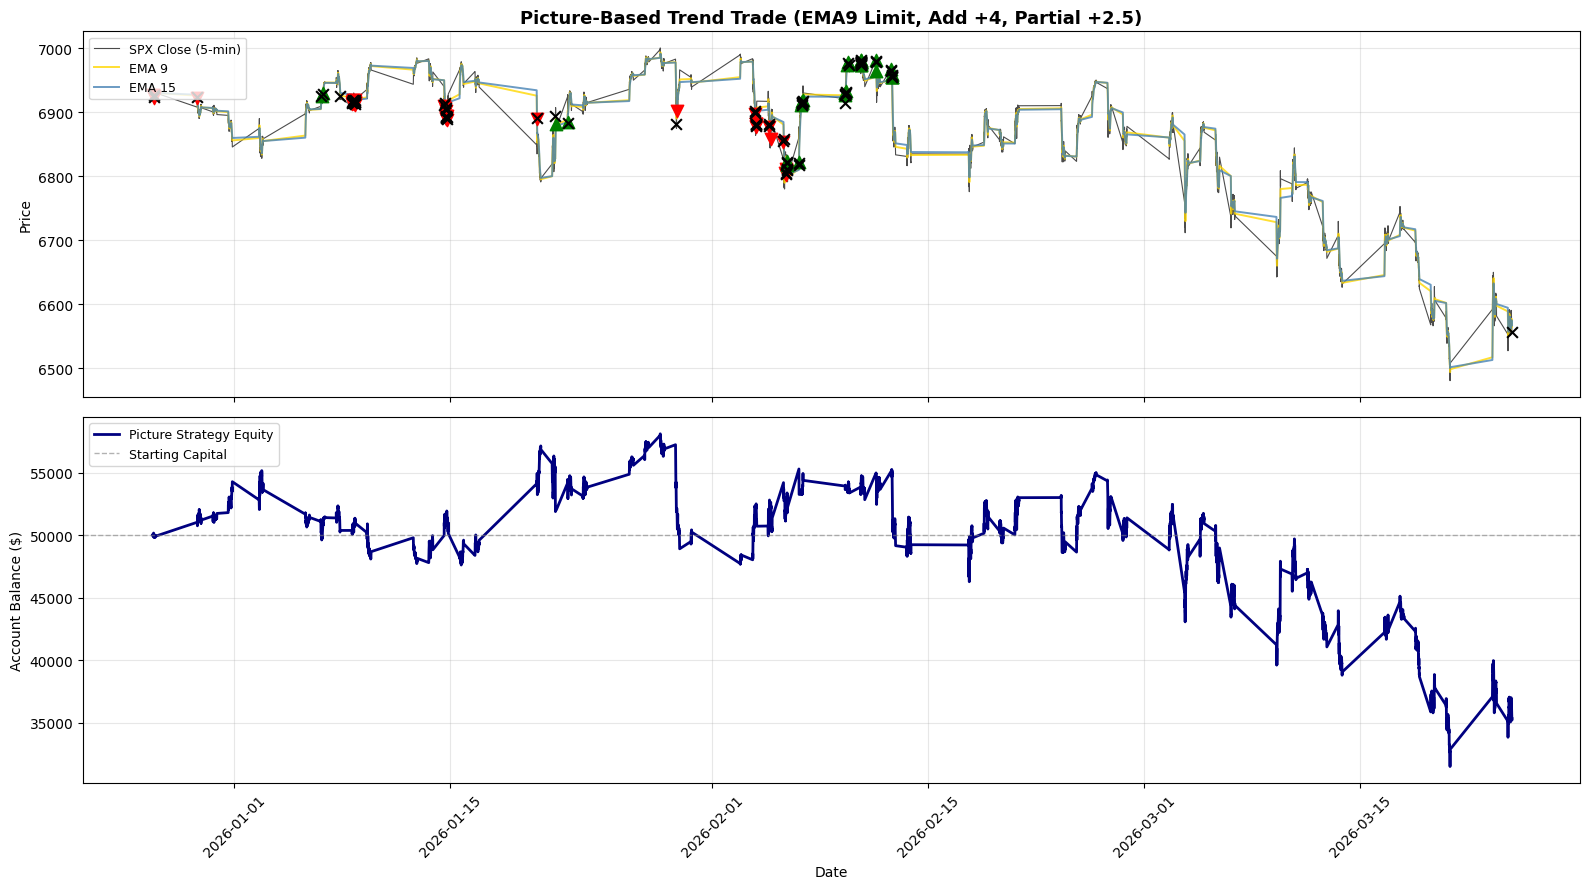

In [27]:
# Picture-Based Strategy Metrics + Chart

if len(pic_trade_log) > 0:
    pic_trades_df = pd.DataFrame(pic_trade_log)
    pic_total_pnl = pic_trades_df['pnl'].sum()
    pic_wins = pic_trades_df[pic_trades_df['pnl'] > 0]
    pic_losses = pic_trades_df[pic_trades_df['pnl'] < 0]
    pic_win_rate = (len(pic_wins) / len(pic_trades_df)) * 100

    pic_profit_factor = (
        pic_wins['pnl'].sum() / abs(pic_losses['pnl'].sum())
        if len(pic_losses) > 0 and abs(pic_losses['pnl'].sum()) > 0
        else float('inf')
    )

    print('=' * 60)
    print('PICTURE-BASED STRATEGY METRICS')
    print('=' * 60)
    print(f"Closed Trades:         {len(pic_trades_df)}")
    print(f"Win Rate:              {pic_win_rate:.1f}%")
    print(f"Profit Factor:         {pic_profit_factor:.2f}")
    print(f"Total P&L:             ${pic_total_pnl:,.2f}")
    print(f"Final Balance:         ${pic_account_balance:,.2f}")
    print('=' * 60)
else:
    print('No closed trades yet for picture-based strategy.')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

ax1.plot(data.index, data['Close'], color='black', linewidth=0.8, alpha=0.7, label='SPX Close (5-min)')
ax1.plot(data.index, data['EMA9'], color='gold', linewidth=1.4, alpha=0.8, label='EMA 9')
ax1.plot(data.index, data['EMA15'], color='steelblue', linewidth=1.4, alpha=0.8, label='EMA 15')

for s in pic_entry_signals:
    marker = '^' if s['direction'] == 'long' else 'v'
    color = 'green' if s['direction'] == 'long' else 'red'
    ax1.scatter(s['time'], s['price'], marker=marker, color=color, s=80, zorder=5)

for s in pic_exit_signals:
    ax1.scatter(s['time'], s['price'], marker='x', color='black', s=60, zorder=5)

ax1.set_title('Picture-Based Trend Trade (EMA9 Limit, Add +4, Partial +2.5)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=9)

pic_eq_index = data.index[30:30 + len(pic_equity_curve)]
ax2.plot(pic_eq_index, pic_equity_curve, color='navy', linewidth=2, label='Picture Strategy Equity')
ax2.axhline(STARTING_CAPITAL, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Starting Capital')
ax2.set_ylabel('Account Balance ($)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()